# Frozen DINOv2-large — Taxonomy Structure Separation
**Successor of `11_OPN_SHR_structure_separation.ipynb`** (binary shrouded/open — archived).
Now the labels are the full architecture taxonomy from the HTML labelling wizard
(`reviewed_patents_Batch_01.xlsx`), one canonical **main image per architecture**
(main architecture only for now).

Each stage answers one question, has explicit pass/fail criteria, and saves its
artefacts to `outputs/analysis_taxonomy/stage<N>/`. A machine-readable
`results.json` and a human `REPORT_11_taxonomy.md` are (re)generated on every run.

| Stage | Question | Pass |
|---|---|---|
| 0 | Are labels, images and embeddings aligned? | 1 row per architecture, 0 unmatched |
| 1 | Are the embeddings valid and non-degenerate? | 0 NaN/Inf/all-zero, cosines not collapsed |
| 2 | Is there non-random global structure? | PC1 ≥ 3× random baseline, organised UMAP |
| 3+ | Clustering / taxonomy alignment / distances / probing | *next iteration* |

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_loader import load_config
from src import labels, taxonomy_analysis as tax

cfg  = load_config()
SEED = cfg['analysis']['seed']
BASE = tax.tax_out(cfg)
print('output dir:', BASE)

output dir: /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_taxonomy


## Stage 0 — Data prep: labels + embeddings + alignment
**Question:** do we have one clean row per architecture — taxonomy labels, an
approved main image, PatSeer metadata, and a DINOv2 embedding — all aligned?
**Input:** wizard long-format xlsx + PatSeer export + main-image PNGs.
**Outputs:** `labels_v1.parquet`, `stage0/coverage_table.csv`, `qc_issues.csv`, `aligned_rows.csv`,
`embeddings/` (extracted here on first run, cached afterwards).
**Pass:** 0 duplicate architectures, 0 unmatched embedding rows.

In [2]:
# schema actually found in the wizard export (documents the input)
schema = labels.inspect_exports(cfg)
display(schema)

prep = tax.stage0_prepare(cfg)
display(prep['qc_issues'])

cov = prep['coverage']
print(f"classes below min_class_count={cfg['taxonomy']['min_class_count']}: "
      f"{int(cov['below_min'].sum())} / {len(cov)}")
display(cov[~cov['below_min']].head(40))   # analyzable classes
display(cov[cov['below_min']].head(40))    # too-small classes (wait for more batches)

9910 rows | 141 distinct Patent_IDs | 2302 distinct (section, subdim, field) triples


,Section,Sub_Dimension,Field,n_rows
0,G1,Architecture Purity,notPureArch,72
1,G1,G1 — Quick Override,g1_quickOverride,72
2,G1,G1 — Uncertain,g1_humanUncertain,72
3,G1,Topology Type,topType,69
4,M1,Boom Group 1,boom1_attach,7
...,...,...,...,...
2297,T2,Image: imgf0003_crop_0_Fu.png,qualityFlag,1
2298,T2,Image: imgf0003_crop_0_Fu.png,rotation_deg,1
2299,T2,Image: imgf0003_crop_0_Fu.png,status,1
2300,T2,Image: imgf0003_crop_1_F6.png,status,1


/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/DINOv2_eVTOL_frozen_Analysis/src/labels.py:146: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & ~long["Field"].astype(str).str.contains(DROP_FIELD_RE)].copy()
/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


[build_canonical] 72 architectures (59 base patents, 20 rows in multi-arch patents); 68 have an approved main image.
[save_canonical] wrote labels_v1.parquet/.csv + dictionary to /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_taxonomy


,issue,n,detail
0,architecture without approved main image,4,"CN106585976A, US2012063897A1, US2019185152A1, ..."


classes below min_class_count=15: 281 / 371


,attribute,class,n,null_pct,below_min
0,G1_notPureArch,False,66,0.0,False
2,G1_topType,SLC — Independent Thrust — Lift + Cruise,29,0.0,False
10,M1_boom1_attach,Wings — To the Wings,26,39.7,False
13,M1_boom1_circSym,False,39,39.7,False
15,M1_boom1_count,True,32,39.7,False
19,M1_boom1_hasProps,True,41,39.7,False
20,M1_boom1_long,Fore — Fore / Forward,25,39.7,False
24,M1_boom1_orient,Long — Longitudinal (fore/aft),29,39.7,False
27,M1_boom1_span,Inboard — Inboard (near root/fuselage),20,39.7,False
32,M1_boom1_sym,True,41,39.7,False


,attribute,class,n,null_pct,below_min
1,G1_notPureArch,True,2,0.0,True
3,G1_topType,TP — Vectored Thrust — Tilt Propulsors,11,0.0,True
4,G1_topType,MR — Wingless — Multirotor,9,0.0,True
5,G1_topType,PTC — Vectored Thrust — Pitch-to-Cruise (Winge...,6,0.0,True
6,G1_topType,CVT — Vectored Thrust — Combined,5,0.0,True
7,G1_topType,TW — Vectored Thrust — Tilt Wing,4,0.0,True
8,G1_topType,TB — Vectored Thrust — Tilt Body (Tailsitter),3,0.0,True
9,G1_topType,RC — Wingless — Rotorcraft,1,0.0,True
11,M1_boom1_attach,Fuselage — To the Fuselage,14,39.7,True
12,M1_boom1_attach,Other — Other,1,39.7,True


## Stage 1 — Embedding sanity check
**Question:** are the extracted embeddings valid and non-degenerate?
**Outputs:** `stage1/qc_embedding_report.csv`, `cosine_histograms.png`.
**Pass:** 0 NaN / Inf / all-zero rows in all 6 matrices; per-dimension variance > 0;
cosine distribution not collapsed to a point.

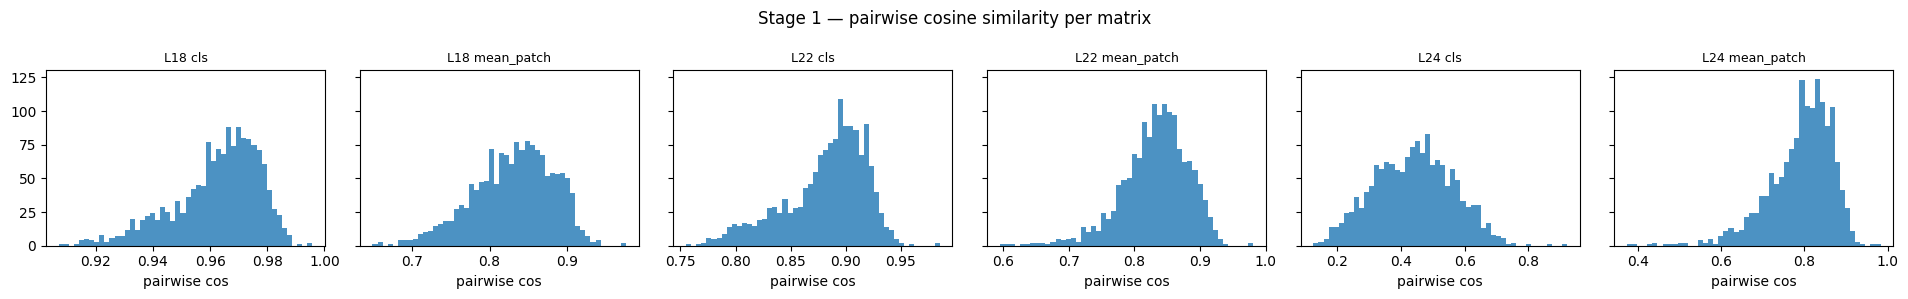

Stage 1 verdict: PASS


,layer,pooling,n_figures,nan_count,inf_count,all_zero_count,exact_duplicate_count,near_dead_dims,dim_var_mean,cos_mean,cos_std,cos_p05,cos_p95
0,18,cls,55,0,0,0,0,0,0.000036,0.962355,0.014964,0.932865,0.981560
1,18,mean_patch,55,0,0,0,0,0,0.000162,0.830838,0.051834,0.737781,0.905529
2,22,cls,55,0,0,0,0,0,0.000113,0.881692,0.037025,0.805541,0.928416
3,22,mean_patch,55,0,0,0,0,0,0.000161,0.831992,0.050360,0.739789,0.904220
4,24,cls,55,0,0,0,0,0,0.000537,0.439823,0.123966,0.232644,0.642345
5,24,mean_patch,55,0,0,0,0,0,0.000200,0.791449,0.076593,0.650831,0.888818


In [3]:
qc = tax.stage1_sanity(prep, cfg)
display(qc[['layer','pooling','n_figures','nan_count','inf_count','all_zero_count',
            'exact_duplicate_count','near_dead_dims','dim_var_mean',
            'cos_mean','cos_std','cos_p05','cos_p95']])

## Stage 2 — Global structure
**Question:** do the embeddings contain non-random structure at all?
**Method:** PCA spectrum vs matched random-Gaussian baseline; pairwise-distance
distribution vs random; intrinsic dimensionality (participation ratio); Hopkins
clustering tendency; UMAP re-colored by each major taxonomy attribute.
**Outputs:** `stage2/pca_stats.csv`, `pca_vs_random.png`, `random_baseline_comparison.png`, `umap_by_attribute.png`.
**Pass:** PC1 ≥ 3× random baseline; distance distribution clearly wider than random; Hopkins > 0.5.
**Fail:** spectrum and distances indistinguishable from random.

I0000 00:00:1783183728.431772 2271032 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


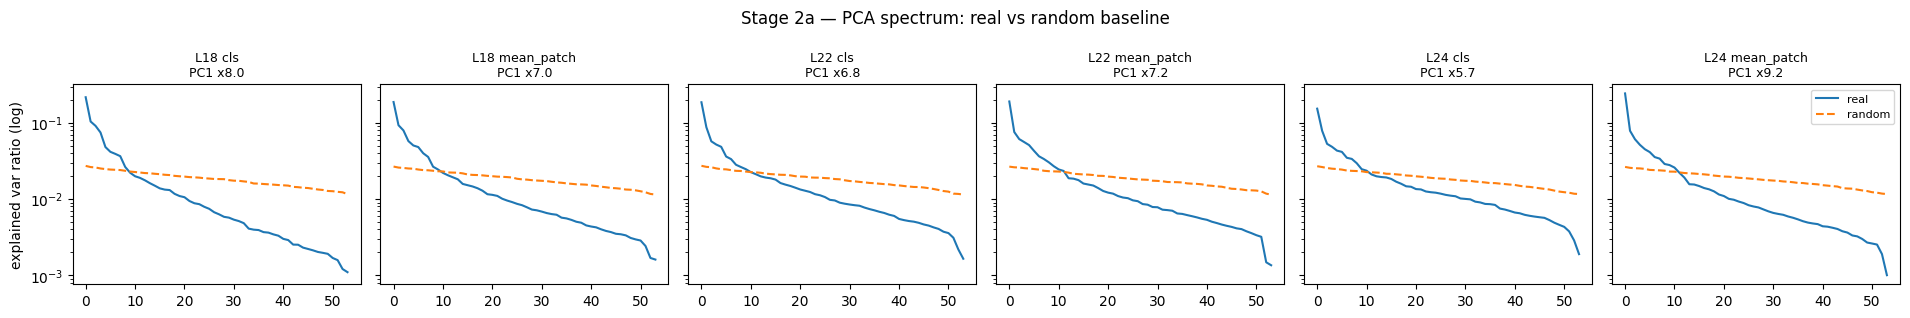

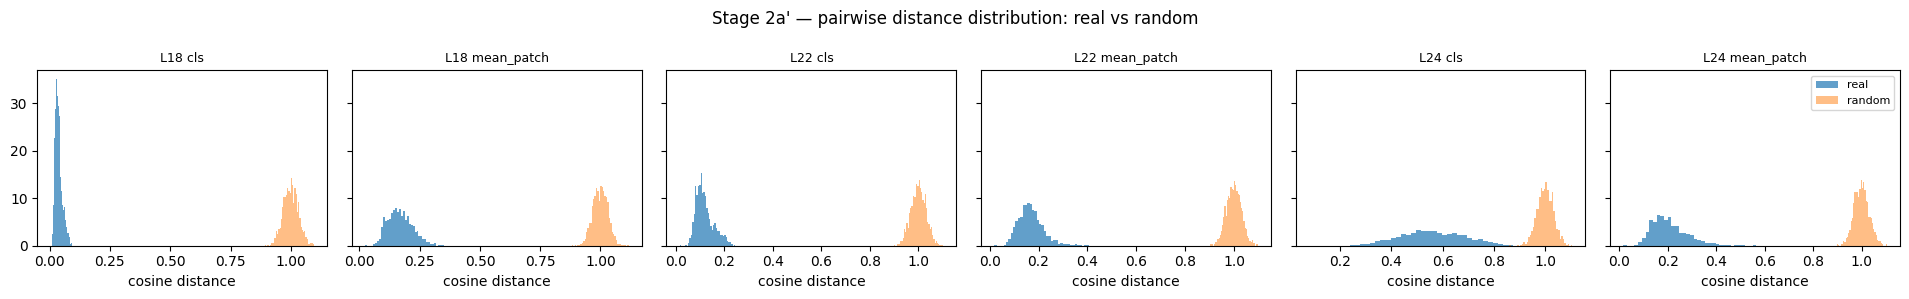

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/DINOv2_eVTOL_frozen_Analysis/src/taxonomy_analysis.py:542: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vals = canon[attr].fillna("∅ missing").astype(str)


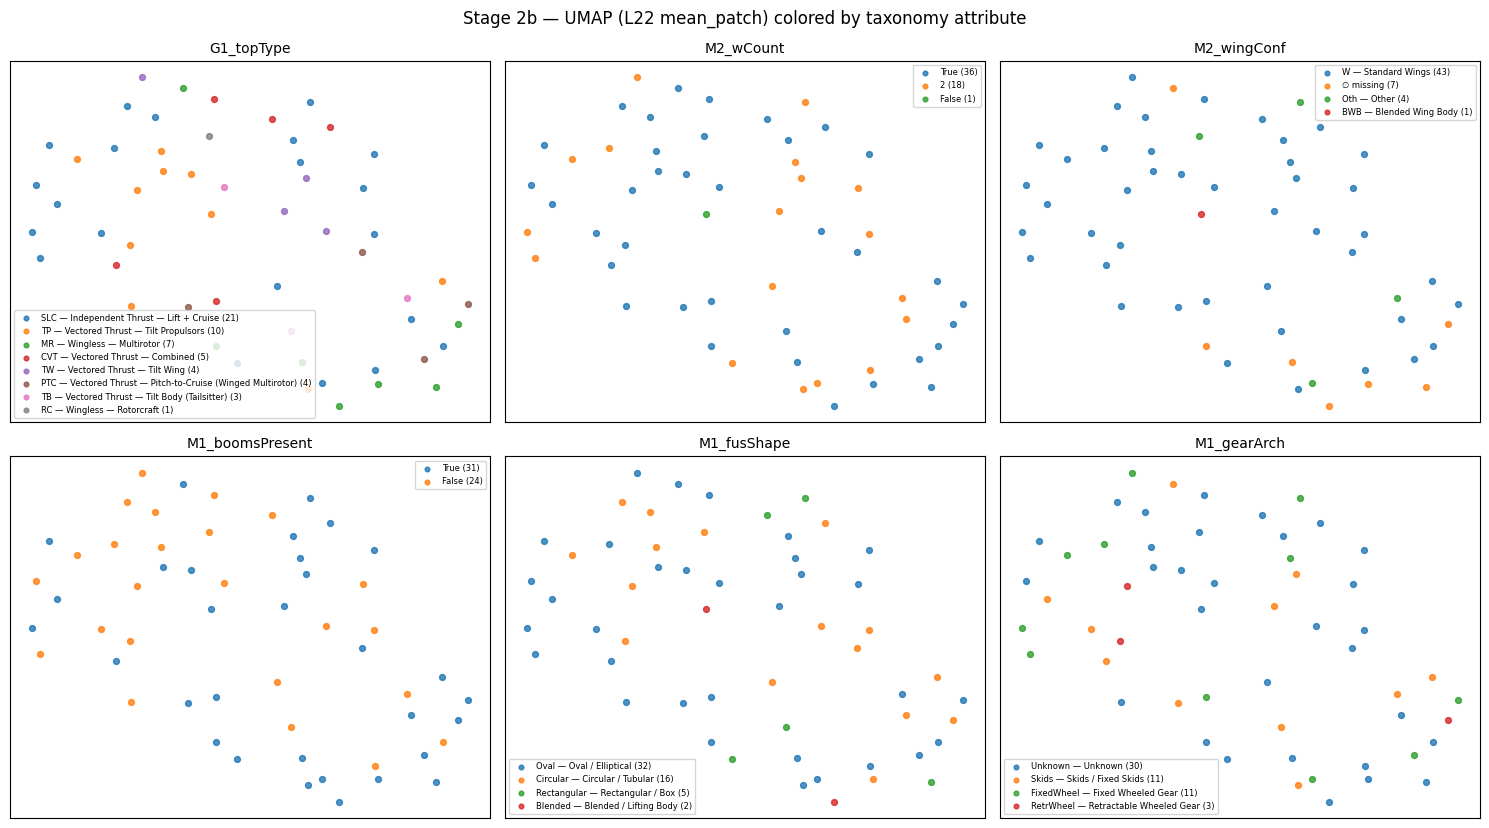

,layer,pooling,pc1_var,pc1_random,pc1_ratio_vs_random,dims_for_90pct,participation_ratio,hopkins
0,18,cls,0.217472,0.027245,7.982200,26,12.0,0.553
1,18,mean_patch,0.188052,0.026690,7.045668,31,14.9,0.514
2,22,cls,0.186774,0.027307,6.839737,34,16.5,0.542
3,22,mean_patch,0.191202,0.026629,7.180324,33,16.0,0.591
4,24,cls,0.153857,0.026968,5.705210,37,20.6,0.613
5,24,mean_patch,0.243993,0.026420,9.235087,31,11.9,0.582


In [4]:
pca_stats = tax.stage2_global_structure(prep, cfg)
display(pca_stats)

## Stage 3 — Unsupervised clustering
**Question:** do coherent groups emerge without using any taxonomy label?
**Method:** PCA to 90%-variance dims, then k-means (k sweep) / agglomerative (ward) / HDBSCAN;
bootstrap-ARI stability of the best k-means partition; dendrogram cut at best k.
**Outputs:** `stage3/cluster_metrics.csv`, `cluster_labels.csv`, `cluster_sizes.csv`, `dendrogram.png`, `umap_clusters.png`.
**Pass:** silhouette > 0.10, bootstrap ARI > 0.60, no extreme fragmentation / one giant cluster.
**Fail:** all noise, one dominant cluster, or unstable partitions.

[stage3] reference L22 mean_patch -> PCA 33 dims (90% var)


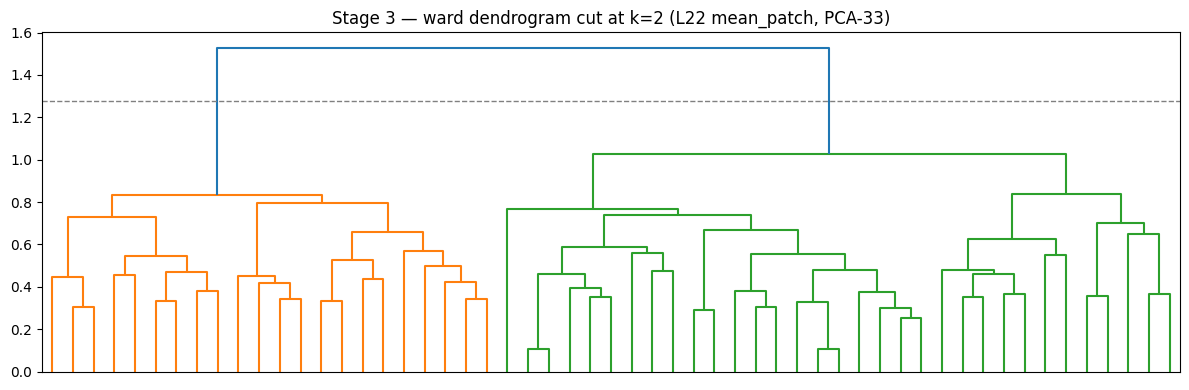

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


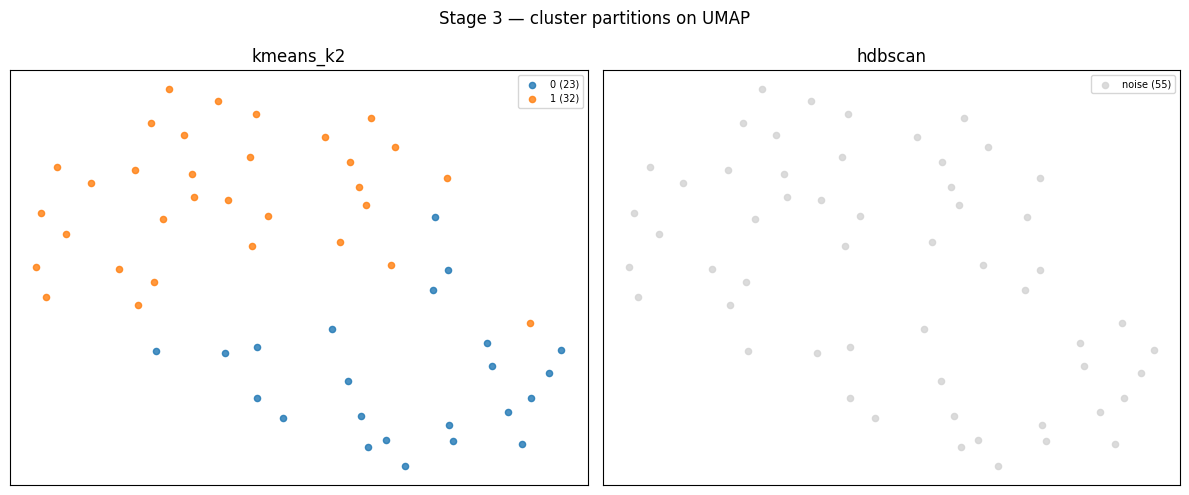

,method,k,silhouette,davies_bouldin,calinski_harabasz,noise_frac
0,kmeans,2,0.134000,2.278371,9.696619,0.0
1,agglomerative,2,0.120291,2.369485,8.764689,0.0
3,agglomerative,3,0.106475,2.544293,6.746864,0.0
2,kmeans,3,0.104976,2.534673,7.133430,0.0
5,agglomerative,4,0.100524,2.098982,5.632611,0.0
6,kmeans,5,0.099621,2.213111,5.430301,0.0
13,agglomerative,10,0.094855,1.708704,4.279772,0.0
8,kmeans,6,0.089630,2.162088,4.843896,0.0
4,kmeans,4,0.088264,2.473713,5.515129,0.0
9,agglomerative,6,0.087152,2.090114,4.822865,0.0


,partition,n_clusters,sizes,n_noise,largest_frac
0,kmeans_k2,2,23/32,0,0.58
1,agglomerative_k2,2,33/22,0,0.60
2,kmeans_k3,3,18/25/12,0,0.45
3,agglomerative_k3,3,12/22/21,0,0.40
4,kmeans_k4,4,13/17/22/3,0,0.40
5,agglomerative_k4,4,22/5/21/7,0,0.40
6,kmeans_k5,5,7/21/11/7/9,0,0.38
7,agglomerative_k5,5,13/9/21/7/5,0,0.38
8,kmeans_k6,6,10/7/3/11/6/18,0,0.33
9,agglomerative_k6,6,21/9/9/7/5/4,0,0.38


In [5]:
metrics3 = tax.stage3_clustering(prep, cfg)
display(metrics3)
import pandas as pd
display(pd.read_csv(BASE / 'stage3' / 'cluster_sizes.csv'))

## Stage 4 — Are the clusters meaningful?
**Question:** do the Stage-3 clusters line up with the taxonomy — or with confounds
(assignee, year, perspective, drawing style)?
**Method:** purity / NMI / ARI of every testable attribute (≥2 classes with ≥5 rows)
and every confound vs the best k-means partition; per-cluster enrichment for the top attributes.
**Outputs:** `stage4/cluster_label_alignment.csv`, `cluster_enrichment.csv`, `alignment_nmi.png`.
**Pass:** best taxonomy attribute out-aligns every confound.
**Fail:** assignee / style aligns at least as well — clusters reflect drawing style, not design.

[stage4] 35 testable attributes + 9 confounds + 2 external labels against partition kmeans_k2


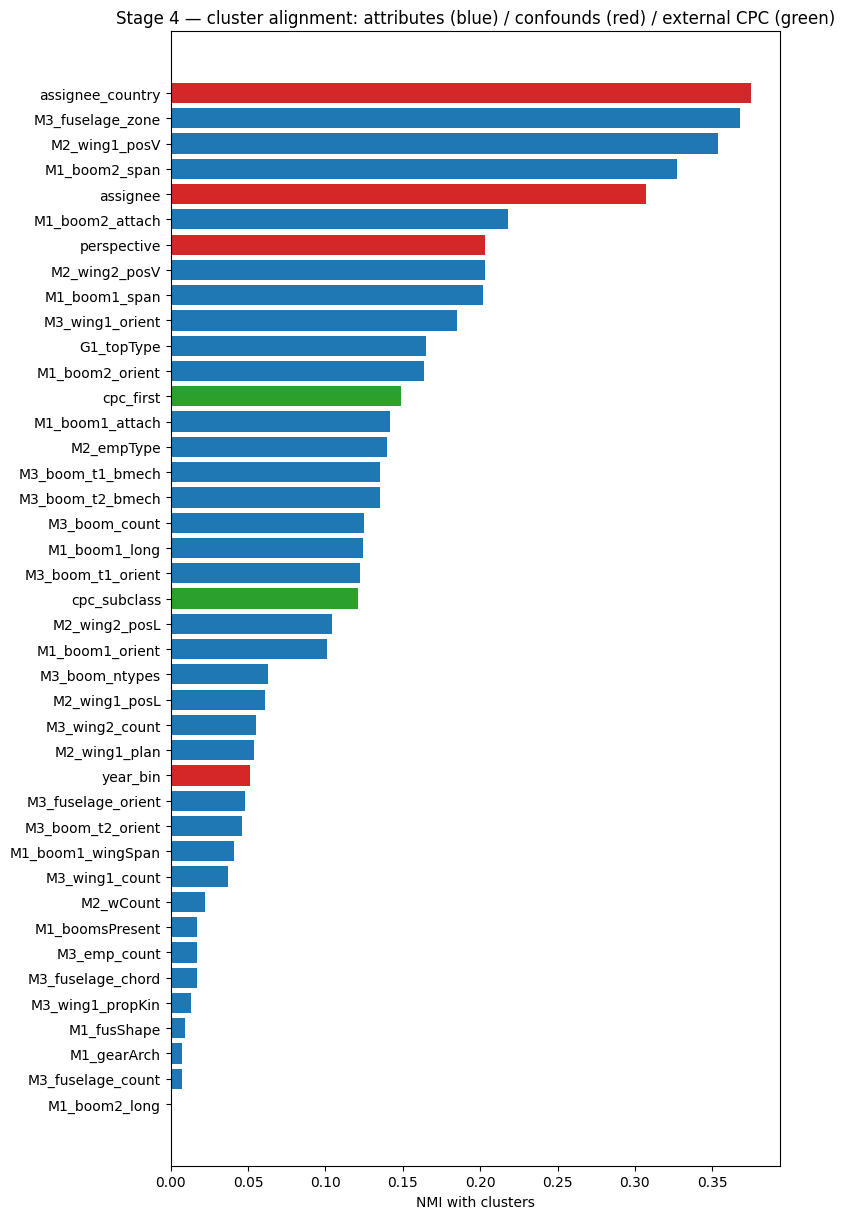

,name,kind,n,n_classes,purity,nmi,ari
0,assignee_country,confound,55,8,0.564,0.375,0.265
1,M3_fuselage_zone,attribute,16,5,0.438,0.368,0.150
2,M2_wing1_posV,attribute,46,4,0.630,0.354,0.310
3,M1_boom2_span,attribute,23,5,0.565,0.327,0.238
4,assignee,confound,55,26,0.236,0.307,0.063
5,M1_boom2_attach,attribute,23,2,0.739,0.218,0.195
6,perspective,confound,55,5,0.673,0.203,0.237
7,M2_wing2_posV,attribute,18,4,0.500,0.203,0.085
8,M1_boom1_span,attribute,31,4,0.516,0.202,0.133
9,M3_wing1_orient,attribute,23,3,0.478,0.185,0.069


,attribute,cluster,n,dominant_class,dominant_share
0,M3_fuselage_zone,0,5,Aft — Aft/Pusher (tail tip),0.40
1,M3_fuselage_zone,1,11,Aft — Aft/Pusher (tail tip),0.45
2,M2_wing1_posV,0,17,Unknown — Unknown,0.35
3,M2_wing1_posV,1,29,High — High / Hub,0.79
4,M1_boom2_span,0,12,Inboard — Inboard (near root/fuselage),0.58
5,M1_boom2_span,1,11,Spanning — Spanning (runs along the attachment),0.55
6,M1_boom2_attach,0,12,Fuselage — To the Fuselage,0.58
7,M1_boom2_attach,1,11,Wings — To the Wings,0.91
8,M2_wing2_posV,0,9,High — High / Hub,0.44
9,M2_wing2_posV,1,9,Low — Low / Down,0.56


In [6]:
align4 = tax.stage4_alignment(prep, cfg)
display(align4.head(25))
import pandas as pd
enrich = pd.read_csv(BASE / 'stage4' / 'cluster_enrichment.csv')
display(enrich)

## Stage 5 — Intra- vs inter-class distances (+ layer comparison)
**Question:** are same-class patents genuinely closer than different-class patents —
and which layer/pooling sees each attribute best?
**Method:** for every testable attribute and the Stage-3 clusters, on **all 6 matrices**:
separation ratio (inter/intra mean cosine distance), Cohen's d, label-permutation p-value (1000 perms).
**Outputs:** `stage5/intra_inter_distance_stats.csv`, `separation_heatmap.png`.
**Pass:** several attributes with sep_ratio > 1 at p < 0.05.
**Fail:** ratios ≈ 1 everywhere — class geometry is arbitrary.

[stage5] skipping M3_boom_t2_bmech — identical to M3_boom_t1_bmech


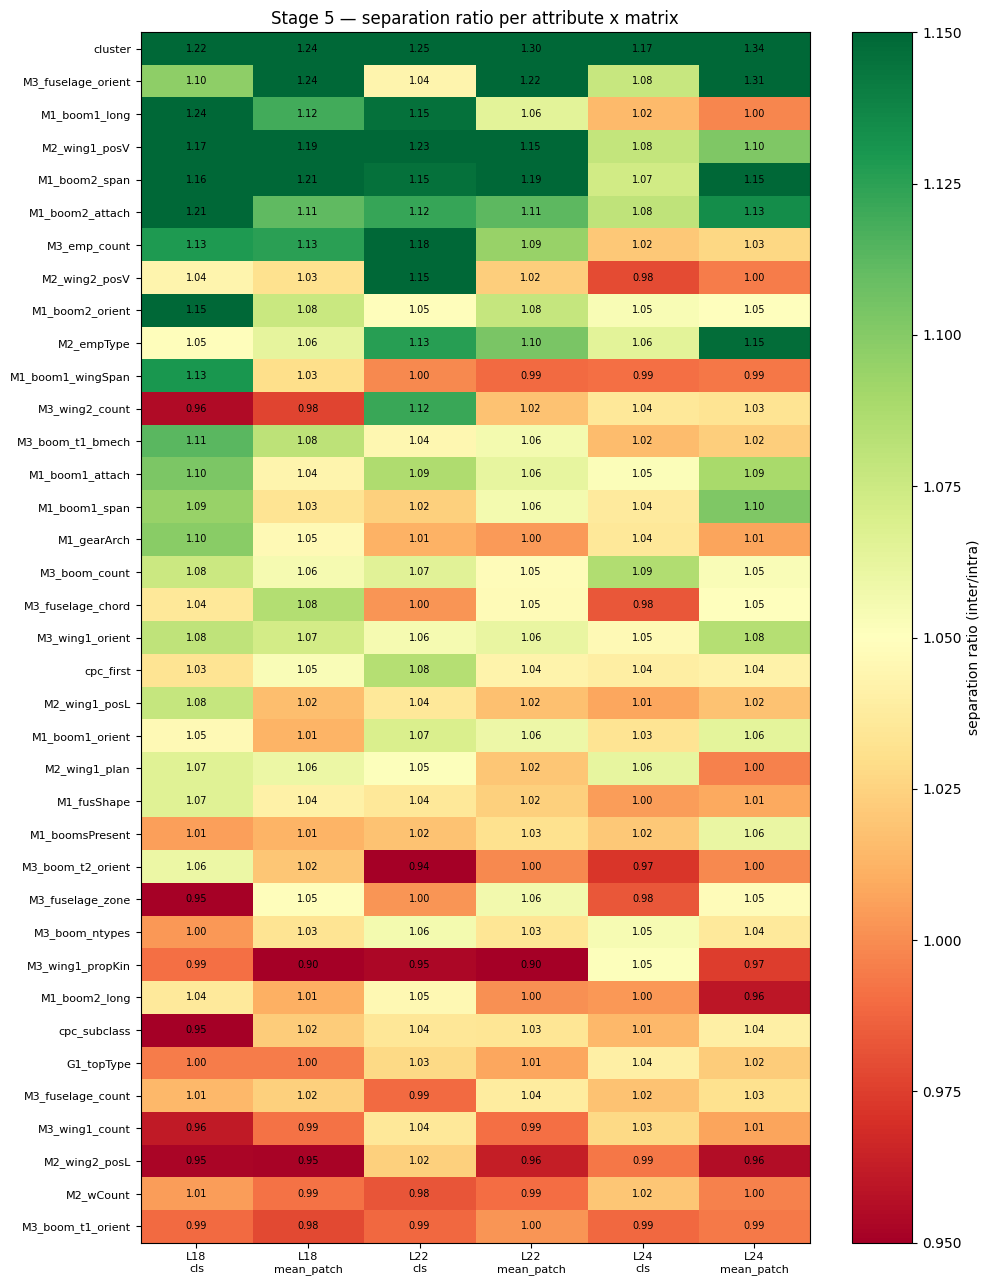

,name,layer,pooling,n,sep_ratio,cohens_d,p_value,intra_mean,inter_mean
0,cluster,24,mean_patch,55,1.335542,0.850798,0.000999,0.178814,0.238814
1,M3_fuselage_orient,24,mean_patch,14,1.311580,0.719872,0.003996,0.203953,0.267501
2,M1_boom1_long,18,cls,31,1.243701,0.559118,0.010989,0.034622,0.043059
3,M2_wing1_posV,22,cls,46,1.225251,0.713860,0.000999,0.099205,0.121552
4,M1_boom2_span,18,mean_patch,23,1.211984,0.622957,0.000999,0.143723,0.174190
5,M1_boom2_attach,18,cls,23,1.209552,0.512773,0.006993,0.031897,0.038581
6,M3_emp_count,22,cls,42,1.177917,0.547321,0.012987,0.102711,0.120985
7,M2_wing2_posV,22,cls,18,1.153208,0.496414,0.008991,0.103753,0.119649
8,M1_boom2_orient,18,cls,23,1.149697,0.372036,0.033966,0.032888,0.037811
9,M2_empType,24,mean_patch,55,1.147034,0.358422,0.001998,0.185337,0.212588


In [7]:
best5 = tax.stage5_distances(prep, cfg)
display(best5.head(25))

## Report
`results.json` + `REPORT_11_taxonomy.md` summarise every stage that ran above.

In [8]:
tax.write_report(cfg)
import json
print(json.dumps(json.loads((BASE / 'results.json').read_text()), indent=2)[:3000])

[write_report] /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis_taxonomy/REPORT_11_taxonomy.md
{
  "stage0": {
    "name": "data prep (labels + embeddings + alignment)",
    "run_date": "2026-07-04",
    "n_architectures_labelled": 72,
    "n_base_patents": 59,
    "n_multi_arch_rows": 20,
    "n_rows_embedded": 55,
    "n_attributes": 180,
    "n_classes_below_min": 281,
    "qc_issues": {
      "architecture without approved main image": 4
    }
  },
  "stage1": {
    "name": "embedding sanity check",
    "run_date": "2026-07-04",
    "pass": true,
    "n_figures": 55,
    "exact_duplicates_max": 0,
    "near_dead_dims_max": 0,
    "cos_std_min": 0.014964324295033696,
    "verdict": "PASS \u2014 embeddings valid"
  },
  "stage2": {
    "name": "global structure (PCA vs random, UMAP)",
    "run_date": "2026-07-04",
    "pc1_ratio_vs_random": {
      "L18_cls": 7.98,
      "L18_mean_patch": 7.05,
      "L22

## Stage 6+ — next iteration
Planned:
- **Stage 6** supervised linear probing per attribute (k-NN + logistic on PCA-50, GroupKFold by base patent, vs majority + shuffled baselines)
- **Stage 7** temporal / genealogical signal (needs more labelled batches)
